# Analyzing the results of the simulations

For each type of jet and each value of $\theta_c$, the list of the resulting dictionaries is put in a Panda Dataframe.

**Input :** `rick_results_<jettype>_<theta_c>.pkl` where `<jettype>` = `TH` (Top-Hat), `G` (Gaussian) or `PL`(Power-Law), and `<theta_c>` = `005` (0.05 radians) or `015` (0.15 radians).

**Units :** 
- $t_{obs}$ in days,
- $F_\gamma$ in photons/cm$^2$/s.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad
import seaborn as sns


## Top-Hat Jet

In [2]:
file_open = open('../data/simulations/all_dico_results_TH_005.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_TH = pd.DataFrame(configs_open)

In [3]:
results_TH[results_TH['observable'] == 'no']

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,38.686122,off,no,3.052637e-13
1,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,26.834367,off,no,1.584455e-09
2,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,37.755654,off,no,1.300312e-12
3,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,35.889246,off,no,3.016270e-12
4,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,32.054523,off,no,5.013602e-11
...,...,...,...,...,...,...,...
994,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,39.479675,off,no,4.174435e-13
995,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,34.303725,off,no,3.907441e-12
996,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,38.329874,off,no,7.274040e-13
997,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,31.619363,off,no,2.347052e-11


In [4]:
print(len(results_TH[(results_TH['axis'] == 'on') & (results_TH['t_obs'] > 4.)]))
print(len(results_TH[(results_TH['axis'] == 'on') & (results_TH['t_obs'] > 7.)]))

3
2


In [5]:
print(len(results_TH[(results_TH['axis'] == 'off') & (results_TH['t_obs'] > 4.)]))
print(len(results_TH[(results_TH['axis'] == 'off') & (results_TH['t_obs'] > 7.)]))

41
33


## Gaussian Jet
#### $\theta_c$ = 0.05 radians

In [6]:
file_open = open('../data/simulations/all_dico_results_G_005.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_G_005 = pd.DataFrame(configs_open)

In [7]:
results_G_005

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,38.234299,off,no,5.497232e-13
1,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,26.204592,off,no,3.593465e-09
2,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,37.182412,off,no,2.733487e-12
3,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.251233,off,no,7.717231e-12
4,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.485611,off,no,1.086638e-10
...,...,...,...,...,...,...,...
995,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,33.855707,off,no,7.085200e-12
996,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,38.116032,off,no,1.022185e-12
997,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.032419,off,no,5.410102e-11
998,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",30.776490,11.743251,on,> 7 days,1.912789e-01


In [8]:
print(len(results_G_005[(results_G_005['axis'] == 'on') & (results_G_005['t_obs'] > 4.)]))
print(len(results_G_005[(results_G_005['axis'] == 'on') & (results_G_005['t_obs'] > 7.)]))

21
11


In [9]:
print(len(results_G_005[(results_G_005['axis'] == 'off') & (results_G_005['t_obs'] > 4.)]))
print(len(results_G_005[(results_G_005['axis'] == 'off') & (results_G_005['t_obs'] > 7.)]))

33
26


#### $\theta_c$ = 0.15 radians

In [10]:
file_open = open('../data/simulations/all_dico_results_G_015.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_G_015 = pd.DataFrame(configs_open)

In [11]:
results_G_015

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.906894,off,no,3.177566e-12
1,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",110.795401,24.294950,off,> 7 days,1.606979e-08
2,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.278966,off,no,9.458897e-12
3,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,33.071464,off,no,3.414498e-11
4,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.009378,off,no,7.728548e-10
...,...,...,...,...,...,...,...
995,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.412299,off,no,5.018328e-11
996,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.611053,off,no,7.171158e-12
997,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.523213,off,no,1.442306e-10
998,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",125.004904,11.037595,on,> 7 days,3.004032e-01


In [12]:
print(len(results_G_015[(results_G_015['axis'] == 'on') & (results_G_015['t_obs'] > 4.)]))
print(len(results_G_015[(results_G_015['axis'] == 'on') & (results_G_015['t_obs'] > 7.)]))

67
47


In [13]:
print(len(results_G_015[(results_G_015['axis'] == 'off') & (results_G_015['t_obs'] > 4.)]))
print(len(results_G_015[(results_G_015['axis'] == 'off') & (results_G_015['t_obs'] > 7.)]))

67
62


## Power-Law Jet
#### $\theta_c$ = 0.05 radians

In [14]:
file_open = open('../data/simulations/all_dico_results_PL_005.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_PL_005 = pd.DataFrame(configs_open)

In [15]:
results_PL_005

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,38.192340,off,no,5.256639e-13
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,25.994705,off,no,4.025163e-09
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,37.066933,off,no,2.755887e-12
3,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,34.808405,off,no,1.204218e-11
4,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.416591,off,no,1.025905e-10
...,...,...,...,...,...,...,...
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,33.824259,off,no,7.273595e-12
996,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,38.110332,off,no,9.746360e-13
997,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.898625,off,no,5.504599e-11
998,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",34.280212,11.629209,on,> 7 days,2.021858e-01


In [16]:
print(len(results_PL_005[(results_PL_005['axis'] == 'on') & (results_PL_005['t_obs'] > 4.)]))
print(len(results_PL_005[(results_PL_005['axis'] == 'on') & (results_PL_005['t_obs'] > 7.)]))

21
14


In [17]:
print(len(results_PL_005[(results_PL_005['axis'] == 'off') & (results_PL_005['t_obs'] > 4.)]))
print(len(results_PL_005[(results_PL_005['axis'] == 'off') & (results_PL_005['t_obs'] > 7.)]))

36
29


#### $\theta_c$ = 0.15 radians

In [18]:
file_open = open('../data/simulations/all_dico_results_PL_015.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_PL_015 = pd.DataFrame(configs_open)

In [19]:
results_PL_015

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.836698,off,no,3.260504e-12
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",133.660520,24.226685,off,> 7 days,1.674366e-08
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.250401,off,no,9.506721e-12
3,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,32.972302,off,no,3.542101e-11
4,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,28.816890,off,no,8.407588e-10
...,...,...,...,...,...,...,...
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.319486,off,no,5.014880e-11
996,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.562873,off,no,7.225954e-12
997,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.508398,off,no,1.447073e-10
998,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",131.928503,11.036125,on,> 7 days,3.009786e-01


In [20]:
print(len(results_PL_015[(results_PL_015['axis'] == 'on') & (results_PL_015['t_obs'] > 4.)]))
print(len(results_PL_015[(results_PL_015['axis'] == 'on') & (results_PL_015['t_obs'] > 7.)]))

68
49


In [21]:
print(len(results_PL_015[(results_PL_015['axis'] == 'off') & (results_PL_015['t_obs'] > 4.)]))
print(len(results_PL_015[(results_PL_015['axis'] == 'off') & (results_PL_015['t_obs'] > 7.)]))

71
66


## Table of all the results 

| Jet Type | $$\theta_c$$ (rad) | Axis | $$t_{obs}$$ (days) | Number of observable afterlows (/1000) |
|:------------:|:----------:|:------:|:---------------:|:--------------------------------------:|
|**TOP-HAT**   |            | **On** |     **> 4**     |                 48                     |
|              |            |        |     **> 7**     |                 39                     |
|              |            |**Off** |     **> 4**     |                 62                     |
|              |            |        |     **> 7**     |                 56                     |
|              |            |        |                 |                                        |
|**GAUSSIAN**  |  **0.05**  | **On** |     **> 4**     |                 20                     |
|              |            |        |     **> 7**     |                 13                     |
|              |            |**Off** |     **> 4**     |                 35                     |
|              |            |        |     **> 7**     |                 32                     |
|              |  **0.15**  | **On** |     **> 4**     |                 42                     |
|              |            |        |     **> 7**     |                 34                     |
|              |            |**Off** |     **> 4**     |                 55                     |
|              |            |        |     **> 7**     |                 52                     |
|              |            |        |                 |                                        | 
|**POWER-LAW** |  **0.05**  | **On** |     **> 4**     |                 22                     |
|              |            |        |     **> 7**     |                 14                     |
|              |            |**Off** |     **> 4**     |                 39                     |
|              |            |        |     **> 7**     |                 32                     |
|              |  **0.15**  | **On** |     **> 4**     |                 42                     |
|              |            |        |     **> 7**     |                 35                     |
|              |            |**Off** |     **> 4**     |                 55                     |
|              |            |        |     **> 7**     |                 52                     |

In [22]:
# can be saved to parquet file format
results_PL_015.to_parquet('../data/simulations/results_PL_015.parquet')

In [23]:
# hack configs function
def hack_configs(results_df):
    config_headers = results_df['config'][0].keys()
    config_dict = dict()
    for key in config_headers:
        config_dict[key] = [results_df['config'][i][key] for i  in range(1000)]
    config_df = pd.DataFrame(config_dict)
    return config_df


In [24]:
# get data frames
configs_TH = hack_configs(results_TH)
configs_G_005 = hack_configs(results_G_005)
configs_G_015 = hack_configs(results_G_015)
configs_PL_005 = hack_configs(results_PL_005)
configs_PL_015 = hack_configs(results_PL_015)

In [25]:
configs_PL_005.head()

,jetType,specType,b,thetaObs,E0,thetaWing,thetaCore,n0,p,epsilon_e,epsilon_B,xi_N,d_L,z
0,4,0,4,1.252967,1.140628e+49,0.086407,0.05,0.394784,2.2,0.1,0.01,1.0,1.248609e+27,0.086
1,4,0,4,1.157801,1.741809e+52,0.127140,0.05,0.673978,2.2,0.1,0.01,1.0,2.770957e+26,0.020
2,4,0,4,1.160908,1.452051e+51,0.103982,0.05,0.001981,2.2,0.1,0.01,1.0,1.310210e+27,0.090
3,4,0,4,1.053030,7.336415e+50,0.248794,0.05,0.025640,2.2,0.1,0.01,1.0,1.372114e+27,0.094
4,4,0,4,1.497104,1.841547e+51,0.097989,0.05,0.088909,2.2,0.1,0.01,1.0,2.770957e+26,0.020


Text(0.5, 1.0, 'PowerLaw 0.05')

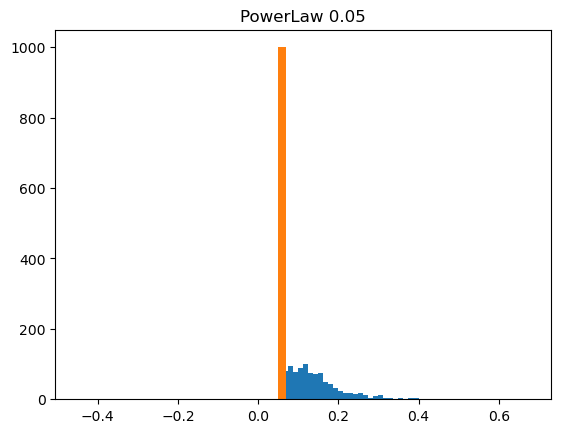

In [26]:
plt.hist(configs_PL_005['thetaWing'], bins=50)
plt.hist(configs_PL_005['thetaCore'], bins=50)
plt.title('PowerLaw 0.05')


Text(0.5, 1.0, 'Top Hat Core')

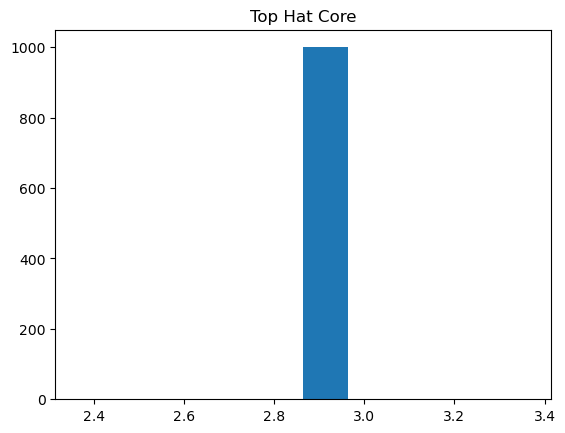

In [27]:
plt.hist(np.degrees(configs_TH['thetaCore']))
plt.title('Top Hat Core')



In [28]:
# join config and results
flat_th = results_TH.join(configs_TH, lsuffix='_name')
flat_G_005 = results_G_005.join(configs_G_005, lsuffix='_name')
flat_G_015 = results_G_015.join(configs_G_015, lsuffix='_name')
flat_PL_005 = results_PL_005.join(configs_PL_005, lsuffix='_name')
flat_PL_015 = results_PL_015.join(configs_PL_015, lsuffix='_name')


In [29]:
# merge all results
mrs = pd.concat([flat_th, flat_G_005, flat_G_015, flat_PL_005, flat_PL_015])
mrs.size

105000

In [30]:
# add tweaked quantities
def add_vars(df):    
    df['log_E0'] = np.log10(df['E0'])
    df['log_tobs'] = np.log10(df['t_obs'])
    df['log_tobs'] = df['log_tobs'].replace(-np.inf, 0)
    df['log_tobs_norm'] = df['log_tobs']/df['log_E0']
    df['thetaObs_deg'] = np.degrees(df['thetaObs'])
    df['thetaCore_deg'] = np.degrees(df['thetaCore'])
    df['thetaWing_deg'] = np.degrees(df['thetaWing'])
    df.head()
    return df


In [31]:
mrs_ext = add_vars(mrs)
mrs.head()

/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,jetType_name,config,t_obs,mag_min,axis,observable,F_gamma,jetType,specType,b,...,epsilon_B,xi_N,d_L,z,log_E0,log_tobs,log_tobs_norm,thetaObs_deg,thetaCore_deg,thetaWing_deg
0,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.0,38.686122,off,no,3.052637e-13,-1,0,4,...,0.01,1.0,1.248609e+27,0.086,49.057144,0.0,0.0,71.789736,2.864789,4.950729
1,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.0,26.834367,off,no,1.584455e-09,-1,0,4,...,0.01,1.0,2.770957e+26,0.020,52.241001,0.0,0.0,66.337123,2.864789,7.284601
2,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.0,37.755654,off,no,1.300312e-12,-1,0,4,...,0.01,1.0,1.310210e+27,0.090,51.161982,0.0,0.0,66.515140,2.864789,5.957726
3,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.0,35.889246,off,no,3.016270e-12,-1,0,4,...,0.01,1.0,1.372114e+27,0.094,50.865484,0.0,0.0,60.334147,2.864789,14.254852
4,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.0,32.054523,off,no,5.013602e-11,-1,0,4,...,0.01,1.0,2.770957e+26,0.020,51.265183,0.0,0.0,85.777749,2.864789,5.614375


In [32]:
# keep only good t_obs
good_mrs = mrs[(mrs['t_obs']>0) & (mrs['t_obs']<300)]

In [33]:
def show_scatter(ax, df, tag):
    _thetaObs = ax[0][0].scatter(df['thetaObs_deg'], df['t_obs'])
    ax[0][0].set_xlabel("thetaObs")
    ax[0][0].set_ylabel("t_obs")
    _thetaCore = ax[0][1].scatter(df['thetaCore_deg'], df['t_obs'])
    ax[0][1].set_xlabel("thetaCore")
    ax[0][1].set_ylabel("t_obs")
    _thetaWing = ax[1][0].scatter(df['thetaWing_deg'], df['t_obs'])
    ax[1][0].set_xlabel("thetaWing")
    ax[1][0].set_ylabel("t_obs")
    _logE0 = ax[1][1].scatter(df['log_E0'], df['t_obs'])
    ax[1][1].set_xlabel("log_E0")
    ax[1][1].set_ylabel("t_obs")


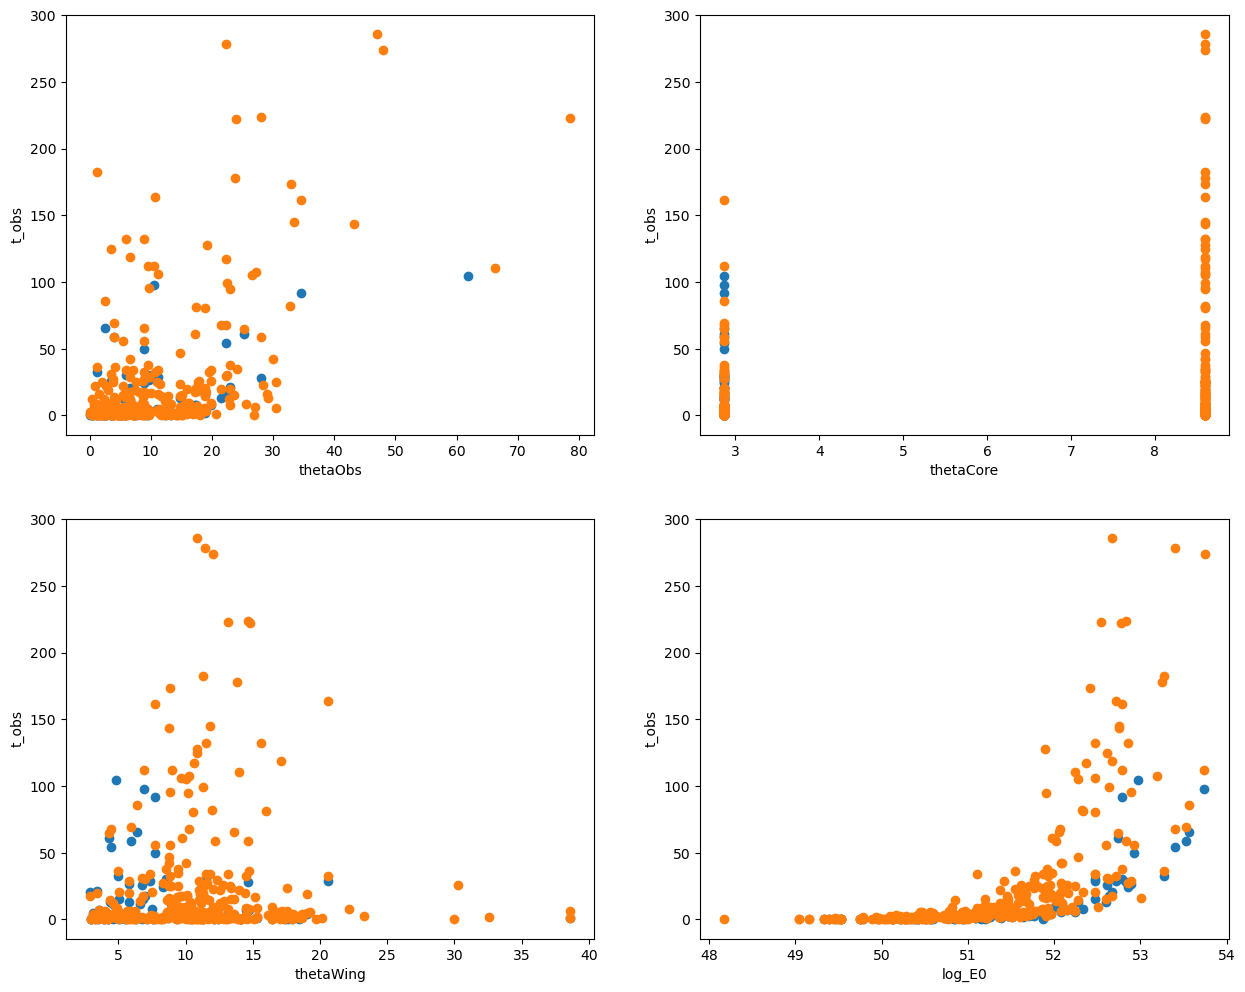

In [34]:
plt.rcParams["figure.figsize"] = [15, 12]
fig, ax = plt.subplots(2, 2)
show_scatter(ax, good_mrs[good_mrs['jetType']==-1], 'TopHat')
show_scatter(ax, good_mrs[good_mrs['jetType']==0], 'Gaussian')


In [35]:
flat_th_ext = add_vars(flat_th)
flat_G_005_ext = add_vars(flat_G_005)
flat_G_015_ext = add_vars(flat_G_015)
flat_PL_005_ext = add_vars(flat_PL_005)
flat_PL_015_ext = add_vars(flat_PL_015)


/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1

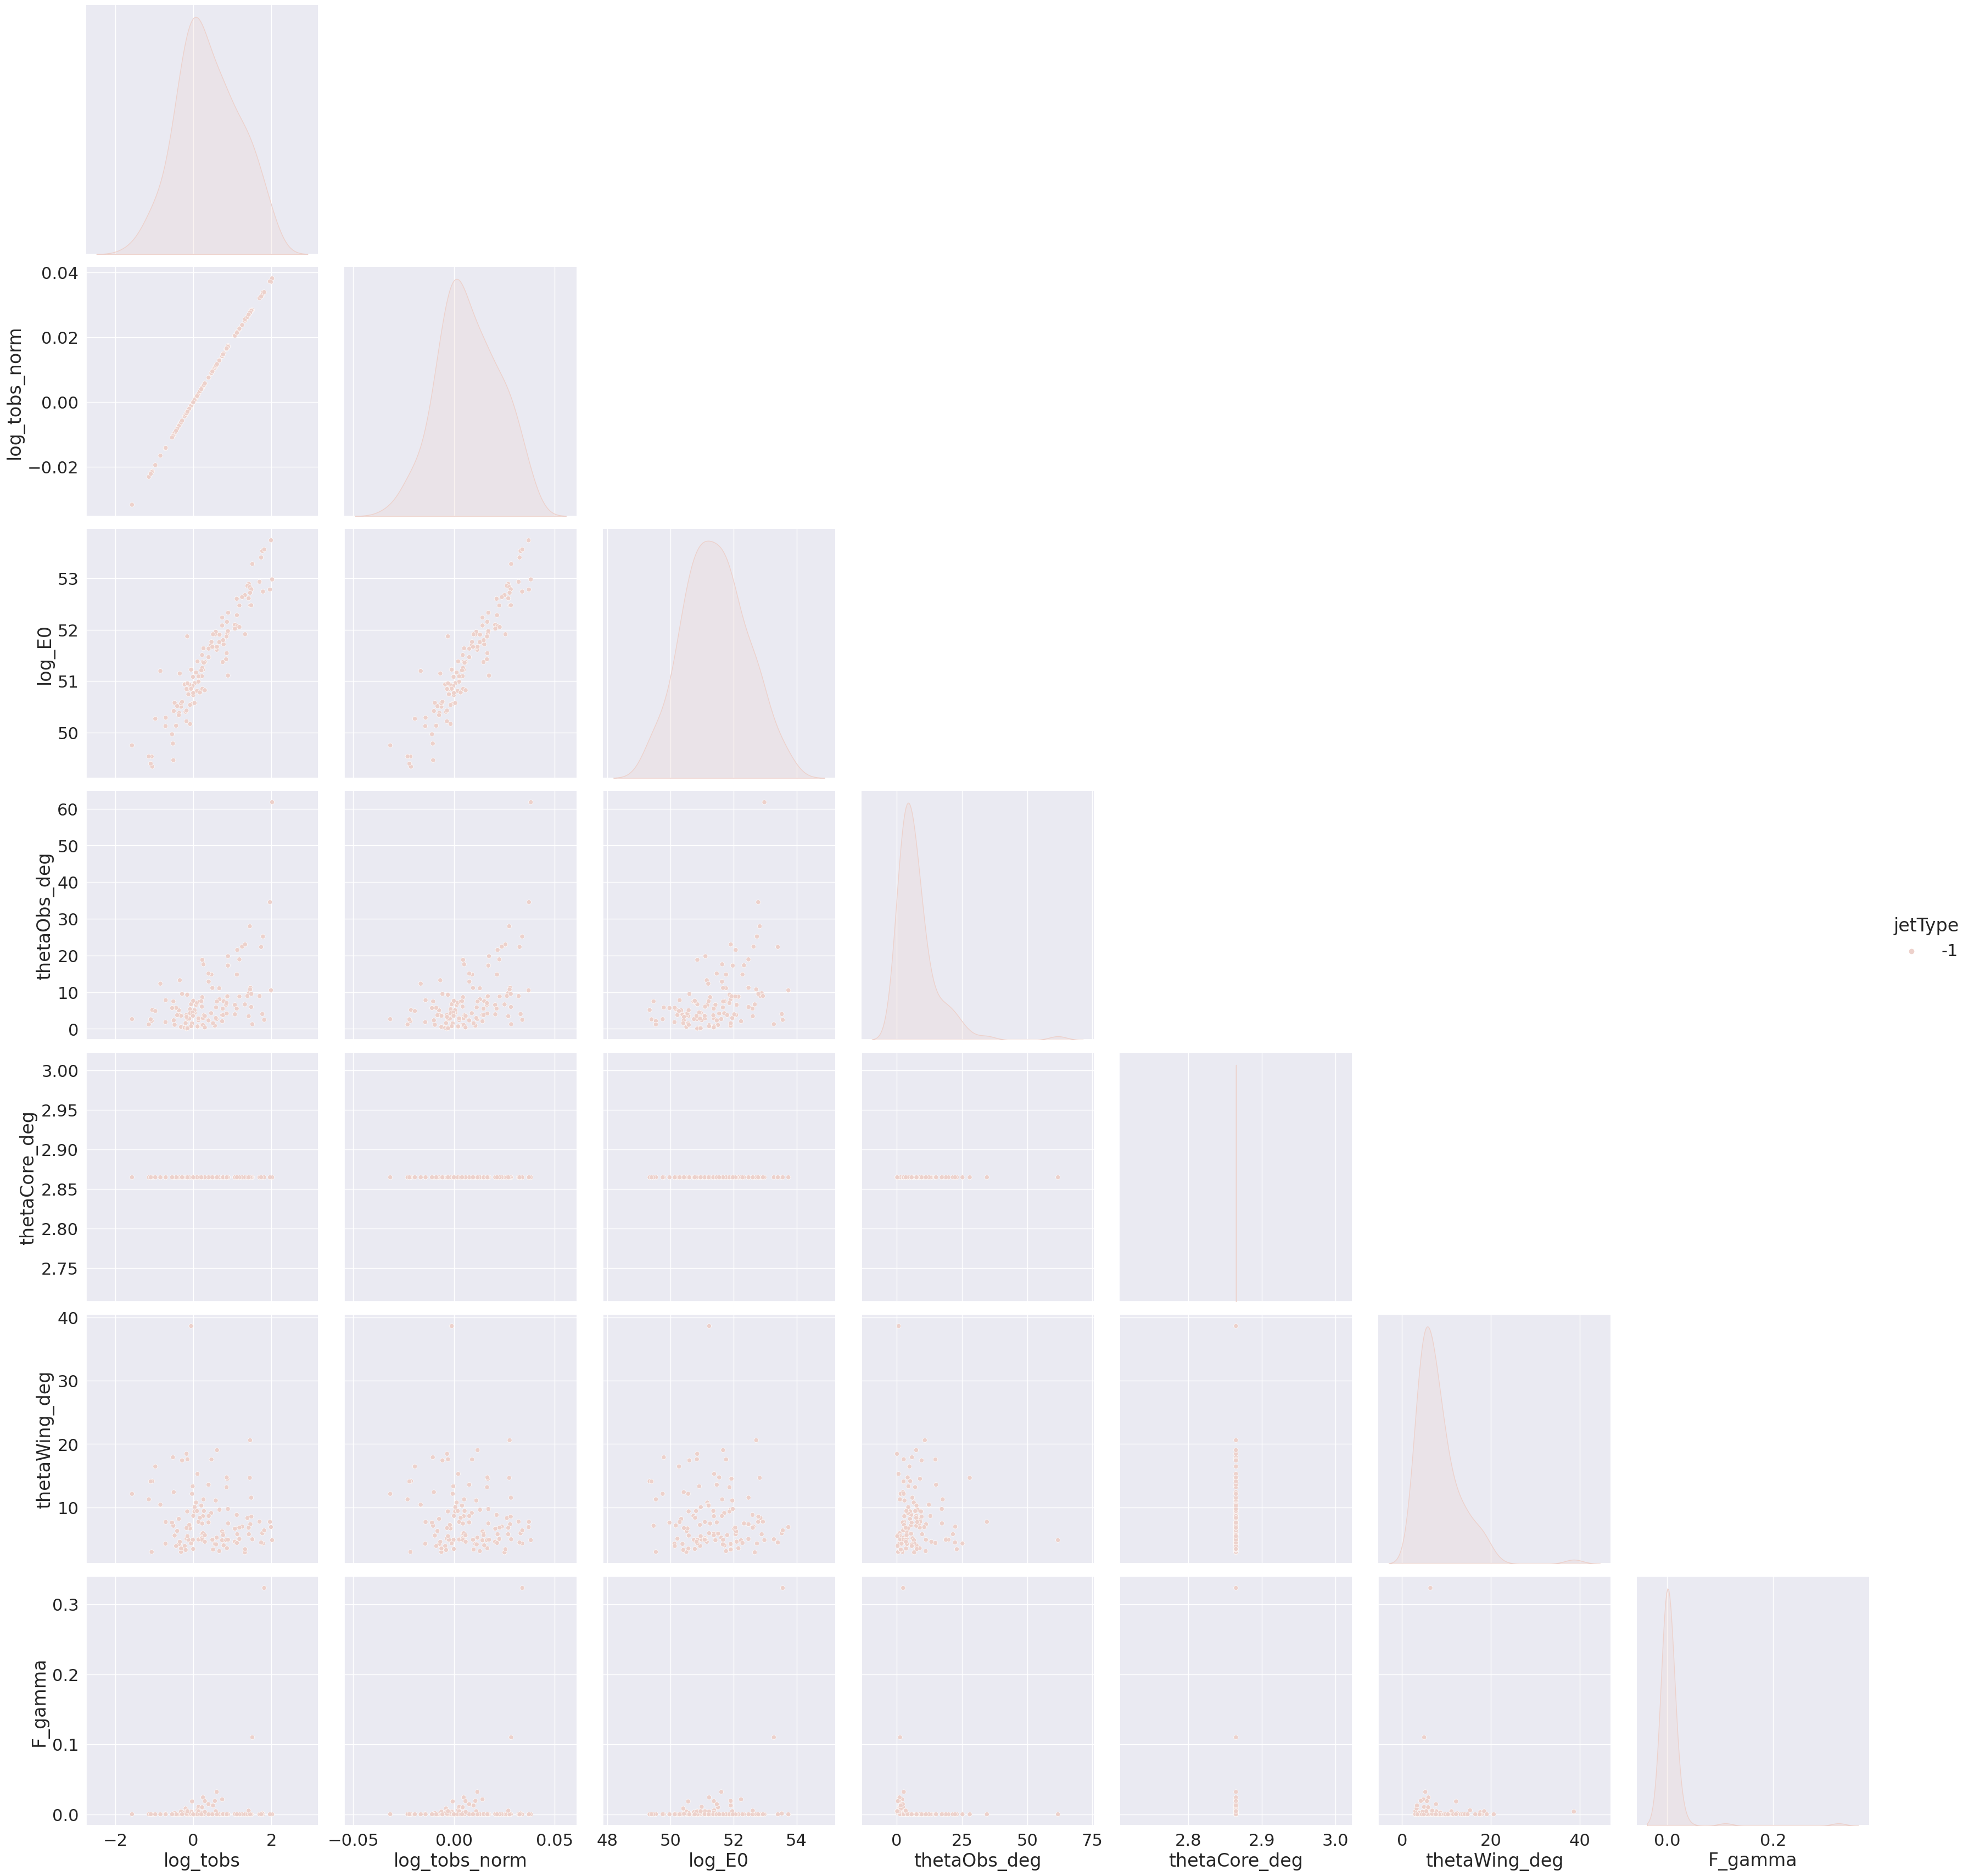

In [36]:
sns.set_theme(style="ticks")
sns.set(font_scale=2)
#vars_to_plot = ['t_obs', 'thetaObs', 'E0_53'] #'mag_min', 'F_gamma', 'jetType', 'E0', , 'thetaWing',
                # 'thetaCore', 'thetaO''n0', 'z']
vars_to_plot = ['log_tobs', 'log_tobs_norm', 'log_E0', 'thetaObs_deg', 'thetaCore_deg', 'thetaWing_deg', 'F_gamma']
#vars_to_plot = ['t_obs', 'E0', 'thetaObs', 'thetaCore', 'thetaWing']

sns.pairplot(flat_th_ext[(flat_th_ext['t_obs']>0) & (flat_th_ext['t_obs']<300)], vars=vars_to_plot, corner=True, hue="jetType", height=5)


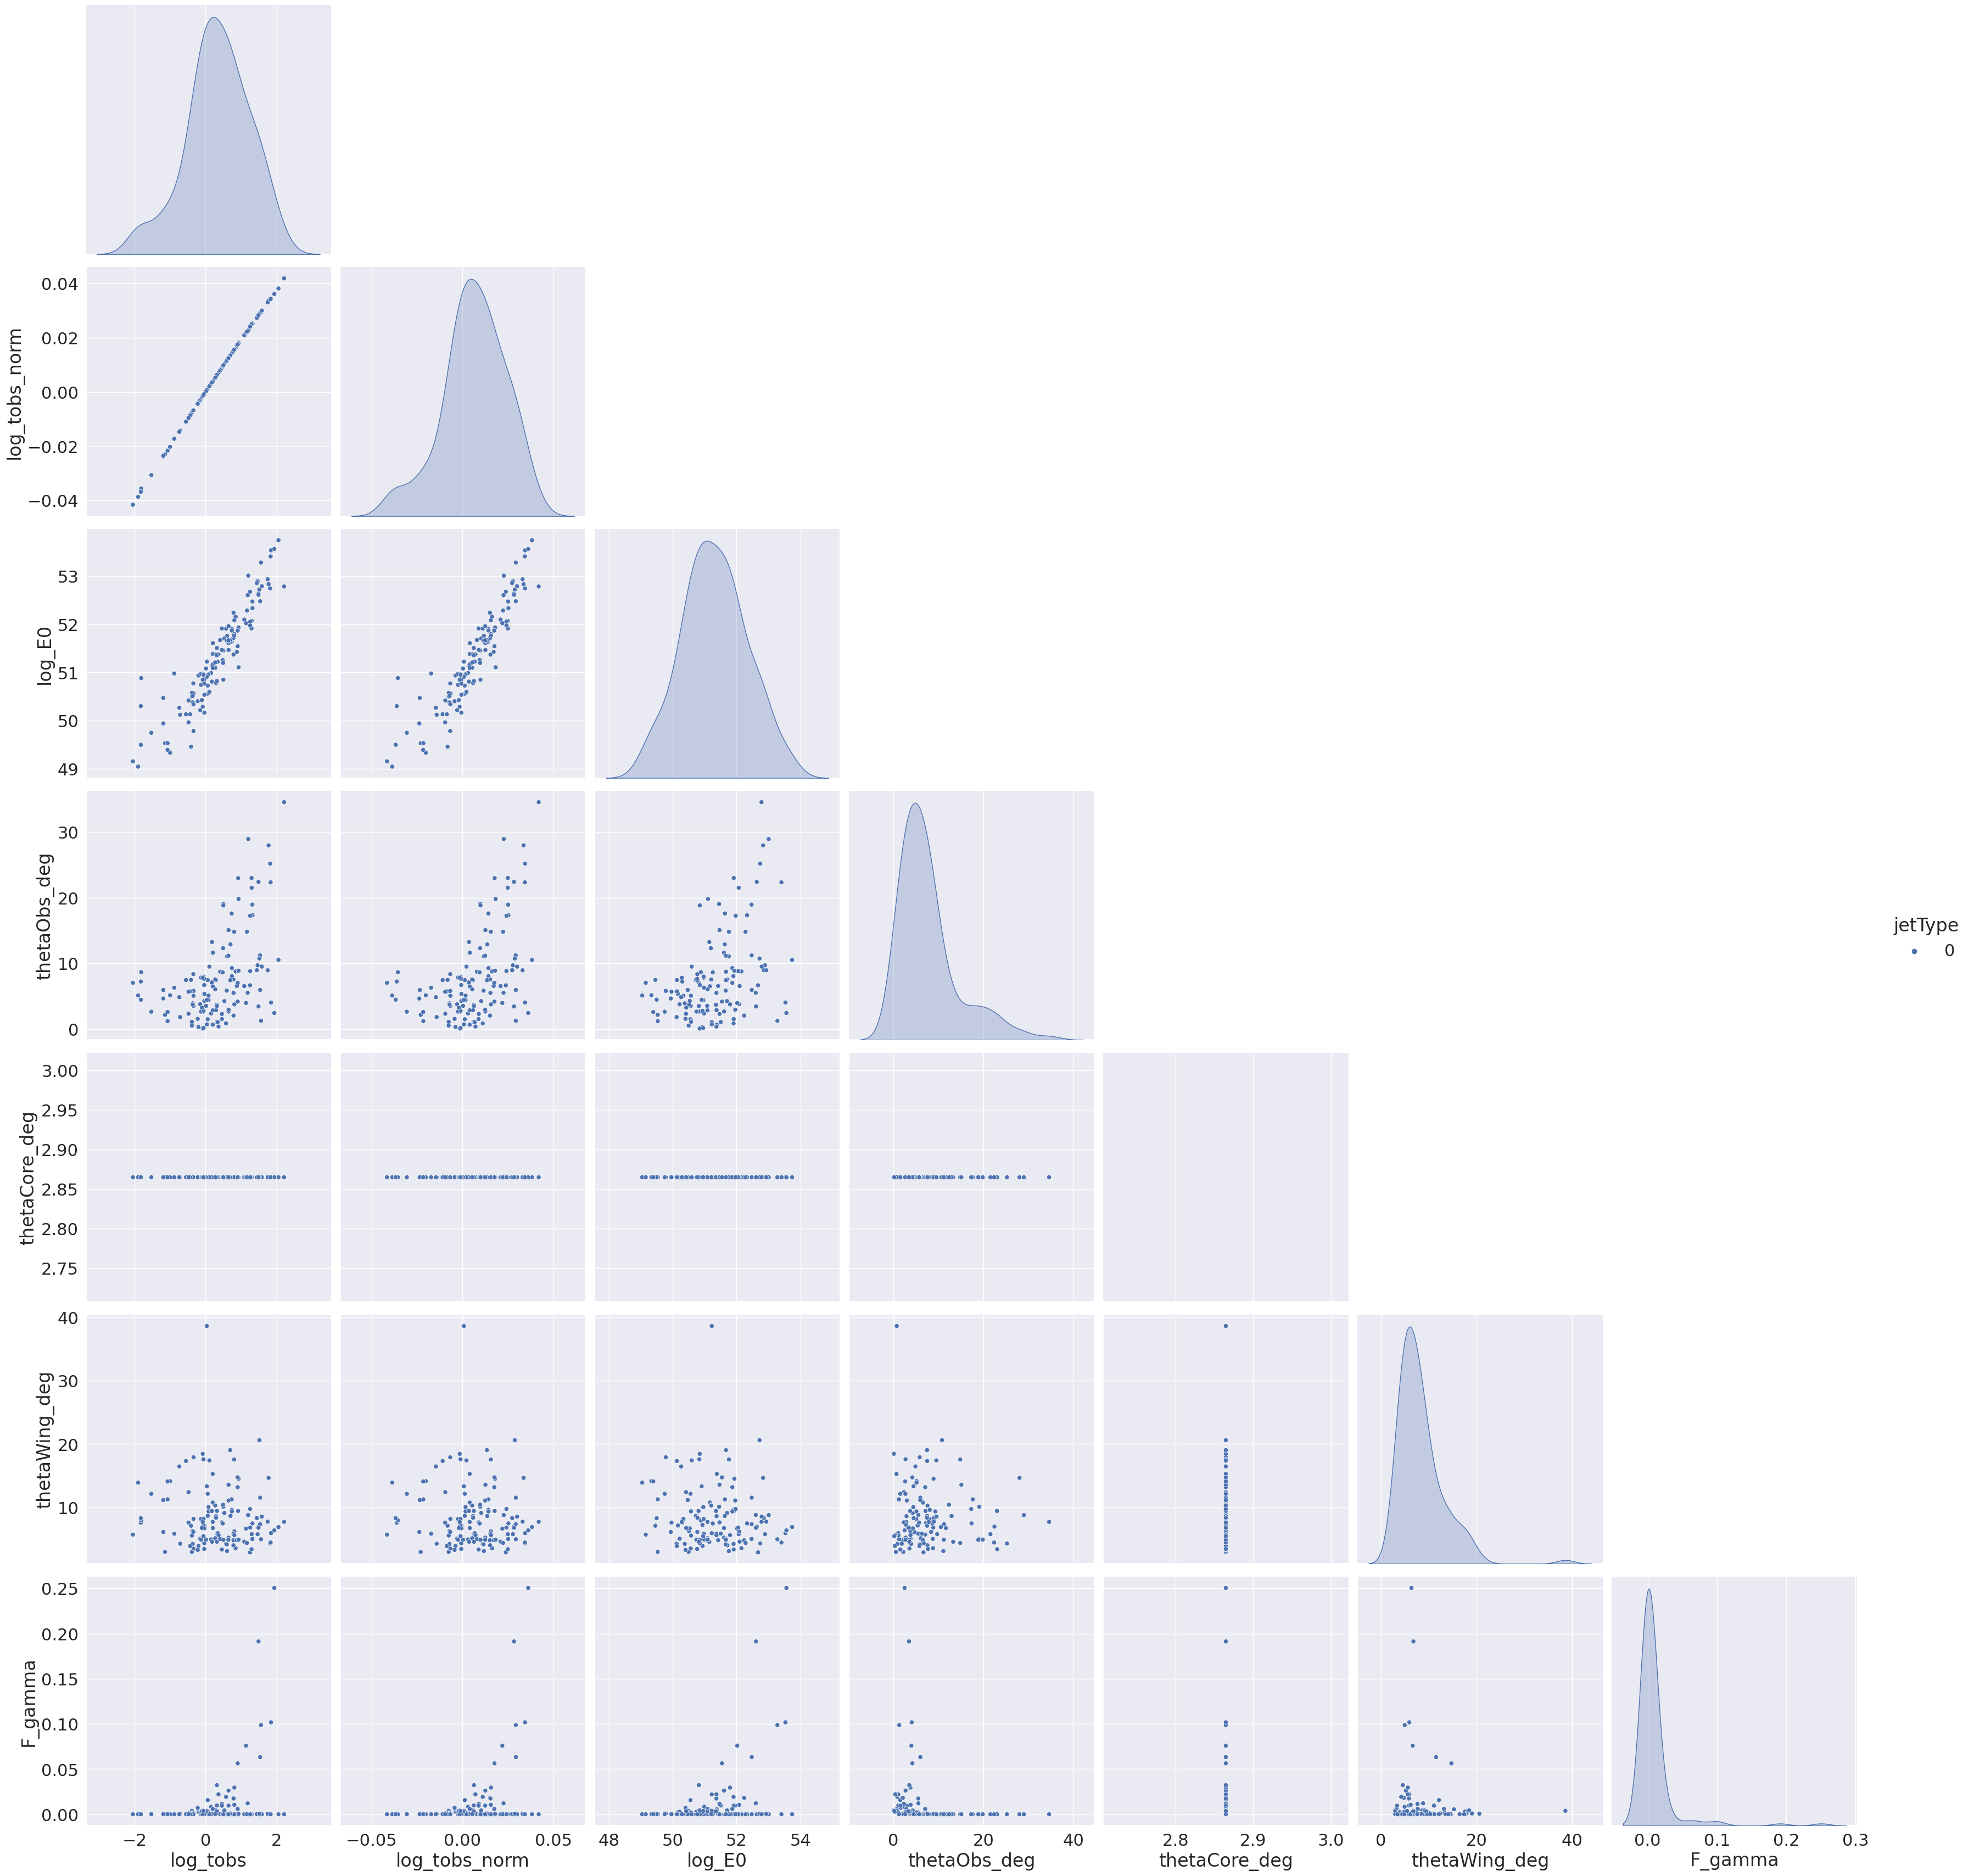

In [37]:
sns.pairplot(flat_G_005_ext[(flat_G_005_ext['t_obs']>0) & (flat_G_005_ext['t_obs']<300)], vars=vars_to_plot, corner=True, hue="jetType", height=5)


<AxesSubplot: >

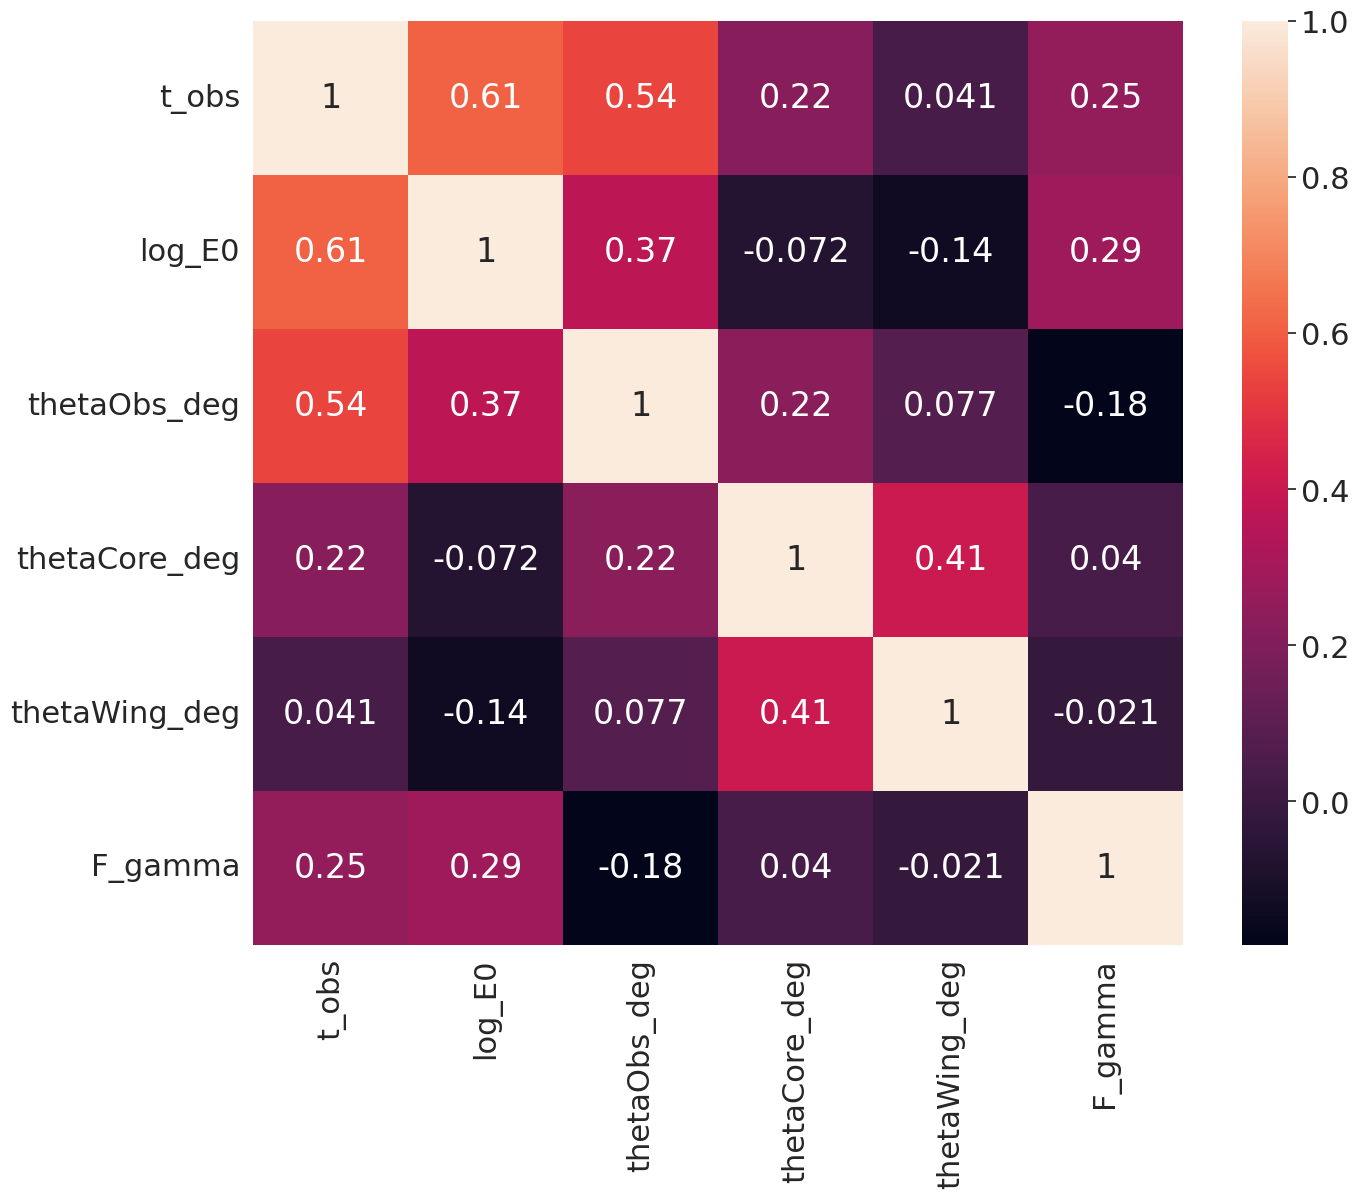

In [38]:
reduced_mrs = good_mrs[['t_obs', 'log_E0', 'thetaObs_deg', 'thetaCore_deg', 'thetaWing_deg', 'F_gamma']]
corrMatrix = reduced_mrs.corr()
sns.heatmap(corrMatrix, annot=True)


/tmp/ipykernel_266301/3893109625.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  full_corrMatrix = good_mrs.corr()


<AxesSubplot: >

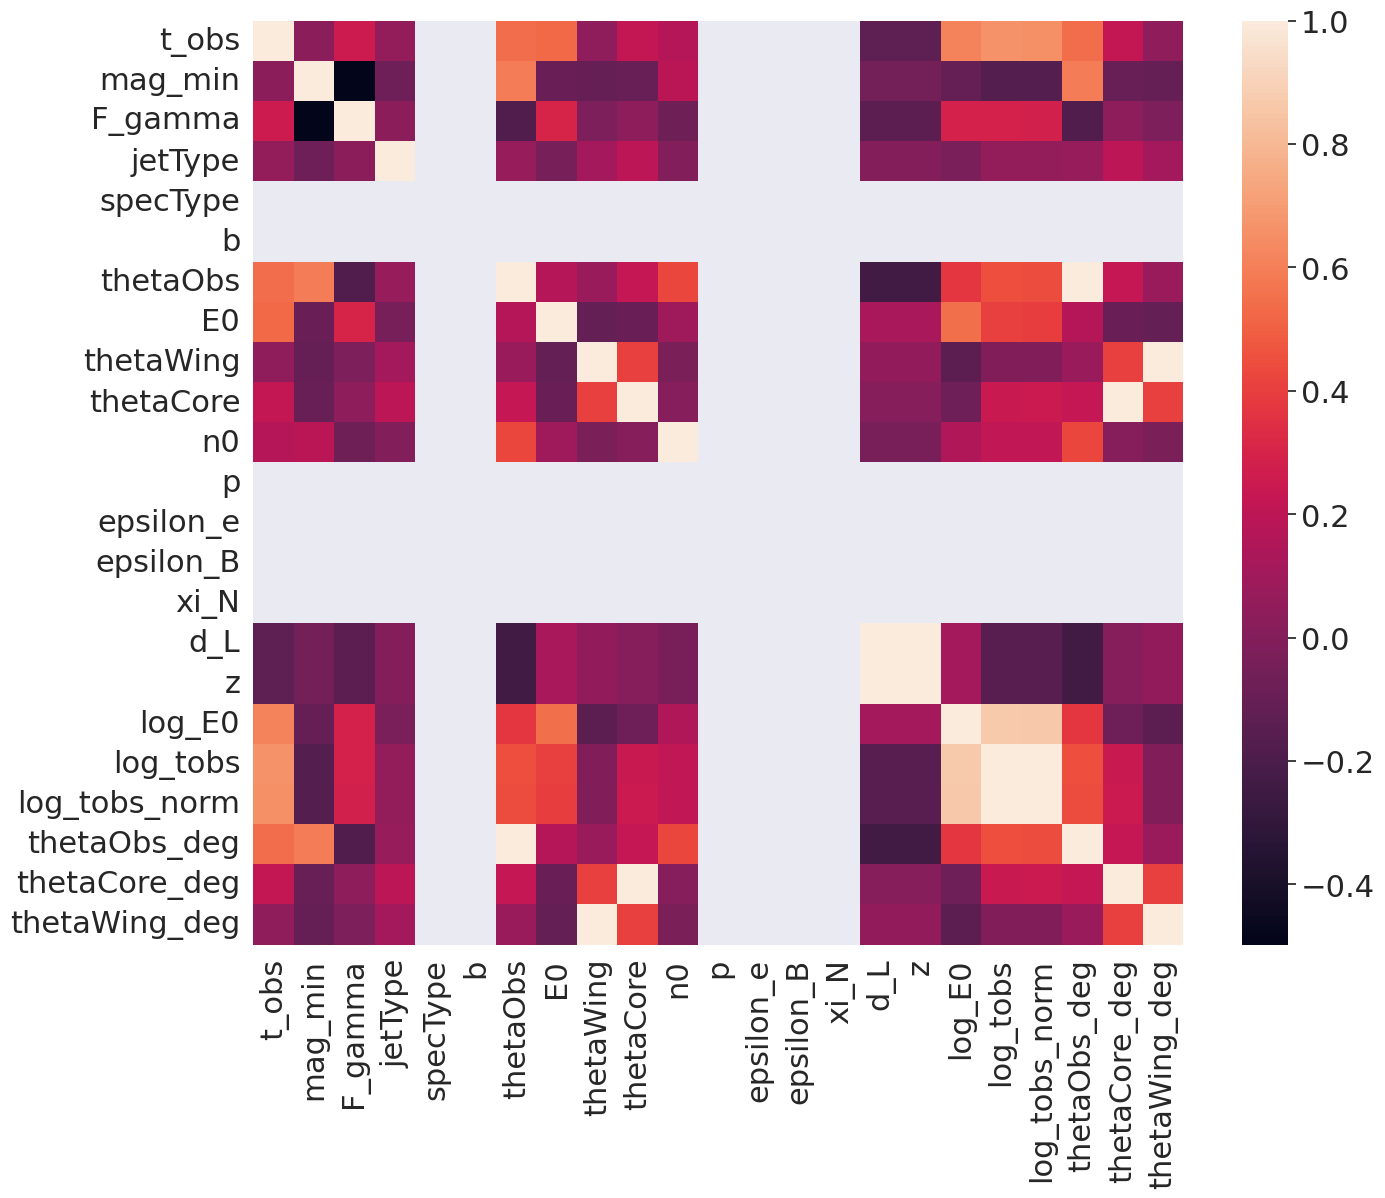

In [39]:
full_corrMatrix = good_mrs.corr()
sns.heatmap(full_corrMatrix, annot=False)


/tmp/ipykernel_266301/628630112.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  my_corrMatrix = my_mrs.corr()


<AxesSubplot: >

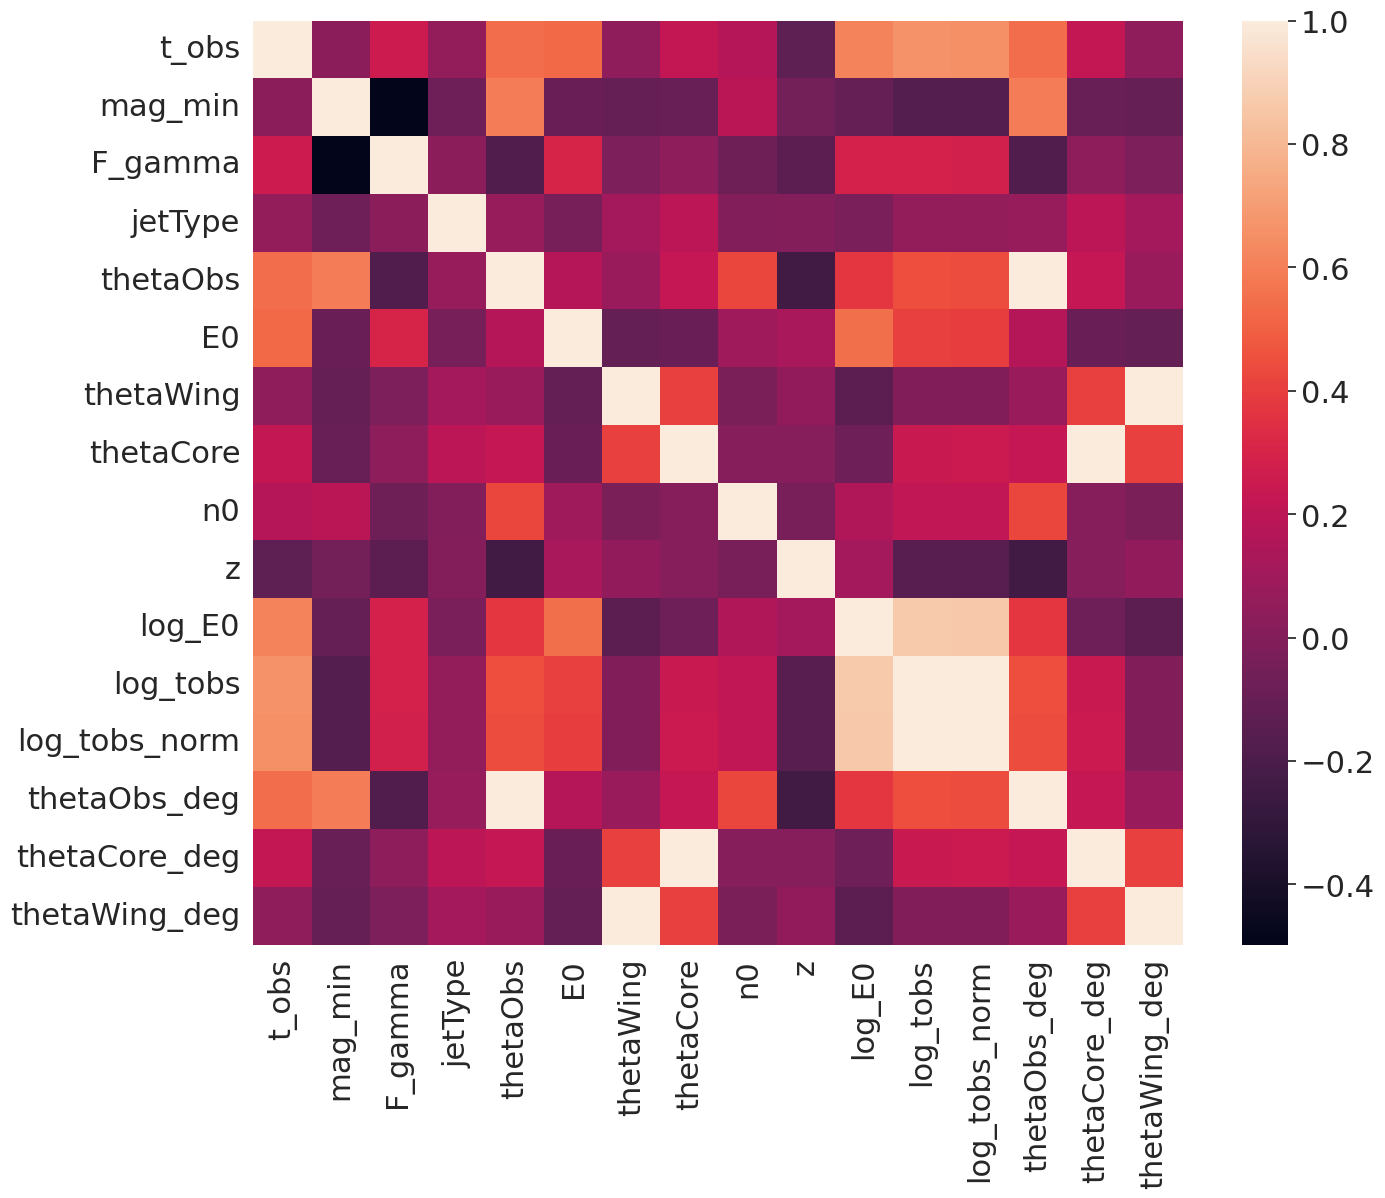

In [40]:
keys_to_remove = ['b', 'specType', 'p', 'epsilon_e', 'epsilon_B', 'xi_N', 'd_L']
my_keys = [x for x in list(good_mrs.keys()) if x not in keys_to_remove]
my_mrs = good_mrs[my_keys]
my_corrMatrix = my_mrs.corr()
sns.heatmap(my_corrMatrix, annot=False)
